# Offline light exposure from SedTRAILS trajectories

This notebook reads saved SedTRAILS particle trajectories, samples Eulerian fields from a SedTRAILS-format input NetCDF, and computes first-pass light exposure diagnostics. The reusable logic lives in `sedtrails.simulation_analysis` so the notebook stays thin.

In [23]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

repo_src = Path.cwd() / "src"
if repo_src.exists():
    sys.path.insert(0, str(repo_src))

import sedtrails.simulation_analysis as sim_analysis
sim_analysis = importlib.reload(sim_analysis)

from sedtrails.pathway_visualizer.colormaps import bathymetry_colormap
from sedtrails.simulation_analysis import (
    attenuation_from_storlazzi,
    combine_attenuation_components,
    compute_clear_sky_surface_light,
    compute_light_exposure,
    plot_particle_bleaching_potential,
    sample_field_at_trajectories,
    surface_light_series,
)
from sedtrails.transport_converter.physics_lib import compute_grain_properties, compute_shear_velocity

## Inputs

`sedtrails_results.nc` provides the saved particle paths. `inlet_sedtrails.nc` provides water depth and suspended sediment concentration on the model grid.

In [24]:
trajectory_path = Path("examples/results/sedtrails_results.nc")
field_path = Path("sample-data/inlet_sedtrails.nc")
if not trajectory_path.exists() and Path("results/sedtrails_results.nc").exists():
    trajectory_path = Path("results/sedtrails_results.nc")
if not field_path.exists() and Path("../sample-data/inlet_sedtrails.nc").exists():
    field_path = Path("../sample-data/inlet_sedtrails.nc")

if not trajectory_path.exists() or trajectory_path.stat().st_size == 0:
    raise FileNotFoundError(f"Trajectory file is missing or empty: {trajectory_path.resolve()}")
if not field_path.exists() or field_path.stat().st_size == 0:
    raise FileNotFoundError(f"Field file is missing or empty: {field_path.resolve()}")

tracks = xr.open_dataset(trajectory_path)
fields = xr.open_dataset(field_path, decode_timedelta=True)

tracks, fields[["waterdepth", "suspended_sed_conc"]]

(<xarray.Dataset> Size: 1MB
 Dimensions:                   (n_populations: 1, n_particles: 30,
                                n_flowfields: 2, n_timesteps: 721)
 Dimensions without coordinates: n_populations, n_particles, n_flowfields,
                                 n_timesteps
 Data variables: (12/22)
     population_name           (n_populations) |S24 24B ...
     population_particle_type  (n_populations) int32 4B ...
     population_start_idx      (n_populations) int64 8B ...
     population_count          (n_populations) int64 8B ...
     population_repr_volume    (n_populations) float64 8B ...
     trajectory_id             (n_particles) int64 240B ...
     ...                        ...
     status_domain             (n_timesteps, n_particles) float32 87kB ...
     status_transported        (n_timesteps, n_particles) float32 87kB ...
     status_released           (n_timesteps, n_particles) float32 87kB ...
     status_mobile             (n_timesteps, n_particles) float32 87kB

## Particle path option

Choose `analysis_mode = "trajectory"` to analyze one saved SedTRAILS particle path, or `analysis_mode = "source"` to hold an idealized particle at the selected particle's initial source position.

In [34]:
analysis_mode = "trajectory" # "trajectory" or "source"
# analysis_mode = "source" # "trajectory" or "source"
selected_particle_index = 0

# Preserve the full trajectory dataset for optional full-size exports later.
tracks_full = tracks if "tracks_full" not in globals() else tracks_full
tracks_all = tracks_full

track_time = tracks_all["time"].values
all_track_x_all = tracks_all["x"].values
all_track_y_all = tracks_all["y"].values
trajectory_ids_all = tracks_all["trajectory_id"].values if "trajectory_id" in tracks_all else np.arange(all_track_x_all.shape[1])

if "population_particle_type" not in tracks_all or "population_id" not in tracks_all:
    raise KeyError(
        "Trajectory file must contain 'population_particle_type' and 'population_id' to run sand-only luminescence analysis."
    )

population_type_values = np.asarray(tracks_all["population_particle_type"].values)
population_id_values = np.asarray(tracks_all["population_id"].values)

population_type_map = {
    0: "sand",
    1: "mud",
    2: "passive",
}

def normalize_population_type(raw_type):
    if isinstance(raw_type, (bytes, bytearray)):
        return raw_type.decode("utf-8", errors="ignore").strip().lower()
    if isinstance(raw_type, str):
        return raw_type.strip().lower()
    if np.isscalar(raw_type) and np.isfinite(raw_type):
        code = int(raw_type)
        return population_type_map.get(code, f"code_{code}")
    return str(raw_type).strip().lower()

normalized_population_types = [normalize_population_type(value) for value in population_type_values]
trajectory_population_types = np.array(
    [
        normalized_population_types[int(pop_id)] if 0 <= int(pop_id) < len(normalized_population_types) else "unknown"
        for pop_id in population_id_values
    ],
    dtype=object,
)

sand_particle_mask = trajectory_population_types == "sand"
sand_particle_indices = np.flatnonzero(sand_particle_mask)

if sand_particle_indices.size == 0:
    unique_population_types = sorted(set(trajectory_population_types.tolist()))
    raise ValueError(
        "No sand populations found in trajectory file. "
        f"Found population types: {unique_population_types}."
    )

non_sand_types = sorted(set(trajectory_population_types[~sand_particle_mask].tolist()))
if non_sand_types:
    skipped_count = int((~sand_particle_mask).sum())
    print(
        "Warning: skipping non-sand trajectories from analysis/plots. "
        f"Skipped {skipped_count} trajectory(ies) with types: {non_sand_types}."
    )

particle_dim = tracks_all["x"].dims[1]
tracks = tracks_all.isel({particle_dim: sand_particle_indices})

all_track_x = tracks["x"].values
all_track_y = tracks["y"].values
trajectory_ids = tracks["trajectory_id"].values if "trajectory_id" in tracks else np.arange(all_track_x.shape[1])

if selected_particle_index < 0 or selected_particle_index >= all_track_x.shape[1]:
    raise IndexError(
        f"selected_particle_index={selected_particle_index} is out of range for {all_track_x.shape[1]} sand trajectory(ies)."
    )

if analysis_mode == "trajectory":
    track_x = all_track_x[:, [selected_particle_index]]
    track_y = all_track_y[:, [selected_particle_index]]
    particle_label = f"trajectory {trajectory_ids[selected_particle_index]}"
elif analysis_mode == "source":
    track_x = np.full((track_time.size, 1), all_track_x[0, selected_particle_index], dtype=float)
    track_y = np.full((track_time.size, 1), all_track_y[0, selected_particle_index], dtype=float)
    particle_label = f"source of trajectory {trajectory_ids[selected_particle_index]}"
else:
    raise ValueError("analysis_mode must be 'trajectory' or 'source'")

print(f"Using {all_track_x.shape[1]} sand trajectory(ies) out of {all_track_x_all.shape[1]} total trajectory(ies).")
print(particle_label, "x=", track_x[0, 0], "y=", track_y[0, 0])

Using 30 sand trajectory(ies) out of 30 total trajectory(ies).
trajectory 0 x= 40167.312 y= 16825.012


In [36]:
# Population summary used for sand-only analysis and plotting.
unique_types, unique_counts = np.unique(trajectory_population_types, return_counts=True)
population_summary = pd.DataFrame(
    {
        "particle_type": unique_types,
        "n_trajectories": unique_counts,
    }
).sort_values(["n_trajectories", "particle_type"], ascending=[False, True], ignore_index=True)

n_total = int(trajectory_population_types.size)
n_sand = int(sand_particle_mask.sum())
n_non_sand = int((~sand_particle_mask).sum())

print(f"Total trajectories: {n_total}")
print(f"Sand trajectories used for analysis/plots: {n_sand}")
print(f"Non-sand trajectories skipped from analysis/plots: {n_non_sand}")

if n_non_sand > 0:
    skipped_types = sorted(set(trajectory_population_types[~sand_particle_mask].tolist()))
    print(f"Skipped particle types: {skipped_types}")

population_summary

Total trajectories: 30
Sand trajectories used for analysis/plots: 30
Non-sand trajectories skipped from analysis/plots: 0


,particle_type,n_trajectories
0,sand,30


## Workflow options

Centralized toggles for offline sampling and map styling.

In [26]:
# Offline forcing behavior
repeat_eulerian_fields = True

# Vertical position options
vertical_position_method = "macdonald_zc"  # "fixed", "saved_z_or_zero", or "macdonald_zc"
optional_fixed_vertical_position = 0.0  # used when vertical_position_method == "fixed"
macdonald_vkarman = 0.41
macdonald_grain_size_mm = 0.250
macdonald_water_density_kg_m3 = 1025.0
macdonald_sediment_density_kg_m3 = 2650.0
macdonald_gravity_m_s2 = 9.81
macdonald_kinematic_viscosity_m2_s = 1.36e-6
macdonald_bed_shear_field_candidates = ["mean_bss_magnitude", "mean_bed_shear_stress", "bed_shear_stress", "max_bss_magnitude"]
apply_trajectory_burial_in_source_mode = False

# Incoming solar radiation options:
# - clear_sky: physically based clear-sky curve from time + latitude/longitude
# - constant_daylight: legacy fixed daytime forcing for quick sensitivity checks
surface_light_mode = "clear_sky"  # "clear_sky" or "constant_daylight"
surface_light_latitude_deg = 53.45
surface_light_longitude_deg = 5.73
surface_light_utc_offset_hours = 1.0
surface_light_atmospheric_transmissivity = 0.75
surface_light_constant_daylight_value = 100.0
surface_light_daylight_start_hour = 6.0
surface_light_daylight_end_hour = 18.0

# MATLAB-style plot styling
matlab_plot_max_x_ticks = 9
matlab_burial_shading_color = "0.85"  # shared helper currently uses this default shade

# Map styling
map_background_colormap_name = "SEAWAD"
map_particle_value_colormap = "plasma"
map_particle_marker_size = 16
map_particle_marker_edgecolor = "k"
map_particle_marker_edgewidth = 0.2

# Echo the active options so the notebook output records the chosen setup.
print("repeat_eulerian_fields", repeat_eulerian_fields)
print("vertical_position_method", vertical_position_method)
print("optional_fixed_vertical_position", optional_fixed_vertical_position)
print("apply_trajectory_burial_in_source_mode", apply_trajectory_burial_in_source_mode)
print("surface_light_mode", surface_light_mode)
print("surface_light_latitude_deg", surface_light_latitude_deg)
print("map background colormap", map_background_colormap_name)

repeat_eulerian_fields True
vertical_position_method macdonald_zc
optional_fixed_vertical_position 0.0
apply_trajectory_burial_in_source_mode False
surface_light_mode clear_sky
surface_light_latitude_deg 53.45
map background colormap SEAWAD


## Sample depth and concentration along paths

The sampler performs linear interpolation in time and triangular linear interpolation in space. `nearest_fallback=True` keeps this exploratory workflow robust for positions just outside the triangulation; for final analyses, inspect those fallback cases explicitly.

In [27]:
grid_time = fields["time"].values
grid_x = fields["net_xcc"].values
grid_y = fields["net_ycc"].values

# Sample water depth along the chosen path.
sampled_depth = sample_field_at_trajectories(
    grid_time,
    grid_x,
    grid_y,
    fields["waterdepth"].values,
    track_time,
    track_x,
    track_y,
    nearest_fallback=True,
    repeat_eulerian_fields=repeat_eulerian_fields,
 )

# Sample suspended sediment concentration along the same path.
sampled_conc = sample_field_at_trajectories(
    grid_time,
    grid_x,
    grid_y,
    fields["suspended_sed_conc"].values,
    track_time,
    track_x,
    track_y,
    sediment_fraction=0,
    nearest_fallback=True,
    repeat_eulerian_fields=repeat_eulerian_fields,
 )

# If available, sample bed shear too so MacDonald z_c can be derived from the forcing.
bed_shear_field_name = next((name for name in macdonald_bed_shear_field_candidates if name in fields), None)
if bed_shear_field_name is not None:
    sampled_bed_shear = sample_field_at_trajectories(
        grid_time,
        grid_x,
        grid_y,
        fields[bed_shear_field_name].values,
        track_time,
        track_x,
        track_y,
        nearest_fallback=True,
        repeat_eulerian_fields=repeat_eulerian_fields,
    ).values
else:
    sampled_bed_shear = None

water_depth_at_particle = sampled_depth.values
depth_avg_concentration = sampled_conc.values

print("repeat_eulerian_fields", repeat_eulerian_fields)
print("sampled water depth range", np.nanmin(water_depth_at_particle), np.nanmax(water_depth_at_particle))
print("sampled concentration range", np.nanmin(depth_avg_concentration), np.nanmax(depth_avg_concentration))
print("bed shear field for MacDonald", bed_shear_field_name)

repeat_eulerian_fields True
sampled water depth range 2.1985620089299243 7.208194249640115
sampled concentration range 0.05200865745376515 5.026068101860082
bed shear field for MacDonald mean_bss_magnitude


In [28]:
# First-pass assumptions:
# - use the available concentration field for both sand-only and mud-only sensitivity runs
# - zero light when buried; full light when beached; no new exposure outside the domain

# Convert sampled suspended-sediment concentration into attenuation coefficients.
components = attenuation_from_storlazzi(
    sed_conc_mud=depth_avg_concentration,
    sed_conc_sand=depth_avg_concentration,
)
kd_sand = combine_attenuation_components(components["mud"], components["sand"], strategy="sand")
kd_mud = combine_attenuation_components(components["mud"], components["sand"], strategy="mud")

track_datetime = track_time.astype("datetime64[ns]")
if surface_light_mode == "clear_sky":
    # Clear-sky forcing from solar geometry + bulk atmospheric transmissivity.
    surface_light = compute_clear_sky_surface_light(
        track_datetime,
        latitude_deg=surface_light_latitude_deg,
        longitude_deg=surface_light_longitude_deg,
        utc_offset_hours=surface_light_utc_offset_hours,
        atmospheric_transmissivity=surface_light_atmospheric_transmissivity,
        output_unit="umol_photons_m2_s",
    )
    incoming_solar_constant = max(float(np.nanmax(surface_light)), 1.0)
    print(
        "clear-sky surface light range [umol photons m^-2 s^-1]:",
        f"{np.nanmin(surface_light):.3f} .. {np.nanmax(surface_light):.3f}",
    )
elif surface_light_mode == "constant_daylight":
    # Legacy forcing: fixed daytime constant and zero at night.
    hour_of_day = (track_datetime.astype("datetime64[h]").astype(int) % 24).astype(float)
    daylight = (hour_of_day >= float(surface_light_daylight_start_hour)) & (
        hour_of_day <= float(surface_light_daylight_end_hour)
    )
    incoming_solar_constant = float(surface_light_constant_daylight_value)
    surface_light = surface_light_series(
        track_datetime,
        constant=incoming_solar_constant,
        daylight_mask=daylight,
    )
    print(
        "constant-daylight surface light range [umol photons m^-2 s^-1]:",
        f"{np.nanmin(surface_light):.3f} .. {np.nanmax(surface_light):.3f}",
    )
else:
    raise ValueError("surface_light_mode must be 'clear_sky' or 'constant_daylight'")

def _macdonald_elevation_above_bed() -> np.ndarray:
    if sampled_bed_shear is None:
        raise ValueError("No bed shear stress field found for MacDonald z_c. Update macdonald_bed_shear_field_candidates.")
    if macdonald_vkarman <= 0.0:
        raise ValueError("macdonald_vkarman must be positive")

    grain_size_m = macdonald_grain_size_mm * 1e-3
    grain_props = compute_grain_properties(
        grain_diameter=grain_size_m,
        gravity=macdonald_gravity_m_s2,
        sediment_density=macdonald_sediment_density_kg_m3,
        water_density=macdonald_water_density_kg_m3,
        kinematic_viscosity=macdonald_kinematic_viscosity_m2_s,
)
    settling_velocity = float(grain_props["settling_velocity"])
    shear_velocity = compute_shear_velocity(
        np.maximum(sampled_bed_shear[:, 0], 0.0),
        water_density=macdonald_water_density_kg_m3,
)

    denominator = macdonald_vkarman * shear_velocity
    ratio = np.full(track_time.shape, np.nan, dtype=float)
    valid = np.isfinite(denominator) & (denominator > 0.0)
    np.divide(settling_velocity, denominator, out=ratio, where=valid)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        zc_fraction = 0.0398 * 10.0 ** (-1.08 * np.tanh(1.2 * np.log(ratio) - 0.4))
    elevation = np.clip(
        water_depth_at_particle[:, 0] * zc_fraction,
        0.0,
        water_depth_at_particle[:, 0],
    )
    print(
        "MacDonald z_c using sampled bed shear:",
        f"grain={macdonald_grain_size_mm:.3f} mm, ws={settling_velocity:.5f} m/s,",
        f"u* range={np.nanmin(shear_velocity):.4f}..{np.nanmax(shear_velocity):.4f} m/s",
    )
    return elevation

# Resolve the particle vertical position before computing exposure.
if vertical_position_method == "fixed":
    if optional_fixed_vertical_position is None:
        raise ValueError("optional_fixed_vertical_position must be set when vertical_position_method='fixed'")
    # Applies to both trajectory and source modes: keep the particle at one fixed elevation above bed.
    particle_elevation_above_bed = np.full(track_time.shape, float(optional_fixed_vertical_position), dtype=float)
elif vertical_position_method == "macdonald_zc":
    # Applies to both modes: derive z_c from sampled bed shear and grain properties.
    particle_elevation_above_bed = _macdonald_elevation_above_bed()
elif vertical_position_method == "saved_z_or_zero":
    if analysis_mode != "trajectory":
        raise ValueError("vertical_position_method='saved_z_or_zero' requires analysis_mode='trajectory'. Use 'fixed' or 'macdonald_zc' for source mode.")
    if "z" in tracks and np.isfinite(tracks["z"].values[:, selected_particle_index]).any():
        z_saved = tracks["z"].values[:, selected_particle_index].astype(float)
        if np.nanmin(z_saved) >= -1e-6:
            particle_elevation_above_bed = np.clip(z_saved, 0.0, water_depth_at_particle[:, 0])
        else:
            print("Saved z contains negative values, so it is not treated as elevation above bed in this notebook.")
            particle_elevation_above_bed = np.zeros(track_time.shape, dtype=float)
    else:
        particle_elevation_above_bed = np.zeros(track_time.shape, dtype=float)
else:
    raise ValueError("vertical_position_method must be 'fixed', 'saved_z_or_zero', or 'macdonald_zc'")

# Pull burial and status diagnostics from the trajectory file when relevant.
if analysis_mode == "source" and not apply_trajectory_burial_in_source_mode:
    burial_depth = None
    status_buried = np.zeros((track_time.size, 1), dtype=bool)
    mixing_depth = None
    in_domain = None
    is_beached = None
else:
    burial_depth = tracks["burial_depth"].values[:, [selected_particle_index]] if "burial_depth" in tracks else None
    status_buried = tracks["status_buried"].values[:, [selected_particle_index]].astype(bool) if "status_buried" in tracks else None
    if status_buried is None and burial_depth is not None:
        status_buried = burial_depth > 1e-6
    if status_buried is None:
        status_buried = np.zeros((track_time.size, 1), dtype=bool)
    mixing_depth = tracks["mixing_depth"].values[:, [selected_particle_index]] if "mixing_depth" in tracks else None
    in_domain = tracks["status_domain"].values[:, [selected_particle_index]].astype(bool) if "status_domain" in tracks else None
    is_beached = tracks["status_beached"].values[:, [selected_particle_index]].astype(bool) if "status_beached" in tracks else None

# Use a unified burial mask so shading, particle position, and light cutoff agree.
burial_active_mask = status_buried[:, 0].copy()
if burial_depth is not None:
    burial_active_mask = burial_active_mask | (burial_depth[:, 0] > 1e-6)

if vertical_position_method == "macdonald_zc" and burial_depth is not None:
    # In MacDonald mode, use the burial depth itself once the particle is buried.
    particle_elevation_above_bed = np.where(
        burial_active_mask,
        np.clip(burial_depth[:, 0], 0.0, water_depth_at_particle[:, 0]),
        particle_elevation_above_bed,
    )

particle_elevation_2d = particle_elevation_above_bed[:, None]

# Run separate sand-only and mud-only exposure calculations for comparison.
sand_result = compute_light_exposure(
    track_datetime,
    water_depth_at_particle,
    kd_sand,
    z=particle_elevation_2d,
    z_convention="height_above_bed",
    surface_light=surface_light,
    burial_depth=burial_depth,
    burial_depth_threshold=1e-6,
    in_domain=in_domain,
    is_beached=is_beached,
    light_threshold=0.01,
    reference_surface_light=incoming_solar_constant,
)

mud_result = compute_light_exposure(
    track_datetime,
    water_depth_at_particle,
    kd_mud,
    z=particle_elevation_2d,
    z_convention="height_above_bed",
    surface_light=surface_light,
    burial_depth=burial_depth,
    burial_depth_threshold=1e-6,
    in_domain=in_domain,
    is_beached=is_beached,
    light_threshold=0.01,
    reference_surface_light=incoming_solar_constant,
)

clear-sky surface light range [umol photons m^-2 s^-1]: 0.000 .. 1045.265
MacDonald z_c using sampled bed shear: grain=0.100 mm, ws=0.00568 m/s, u* range=0.0050..0.0760 m/s


In [29]:
selected_trajectory_id = trajectory_ids[selected_particle_index]
summary = pd.DataFrame({
    "mode": [analysis_mode],
    "particle": [particle_label],
    "trajectory_id": [selected_trajectory_id],
    "sand_cumulative_light_dose": sand_result.cumulative_light_dose[-1],
    "sand_equivalent_sunlight_hours": sand_result.equivalent_sunlight_hours[-1],
    "sand_time_above_threshold_s": sand_result.time_above_threshold[-1],
    "mud_cumulative_light_dose": mud_result.cumulative_light_dose[-1],
    "mud_equivalent_sunlight_hours": mud_result.equivalent_sunlight_hours[-1],
    "mud_time_above_threshold_s": mud_result.time_above_threshold[-1],
    "mean_sampled_depth_m": np.nanmean(water_depth_at_particle, axis=0),
    "mean_sampled_concentration_kg_m3": np.nanmean(depth_avg_concentration, axis=0),
})
summary

,mode,particle,trajectory_id,sand_cumulative_light_dose,sand_equivalent_sunlight_hours,sand_time_above_threshold_s,mud_cumulative_light_dose,mud_equivalent_sunlight_hours,mud_time_above_threshold_s,mean_sampled_depth_m,mean_sampled_concentration_kg_m3
0,trajectory,trajectory 0,0,1.412229e+06,0.375298,183600.0,2.774263e+06,0.737257,195000.0,5.328634,0.310596


## Reproduction of original Matlab light exposure plot

This reproduces the old diagnostic plot structure for the currently selected path.

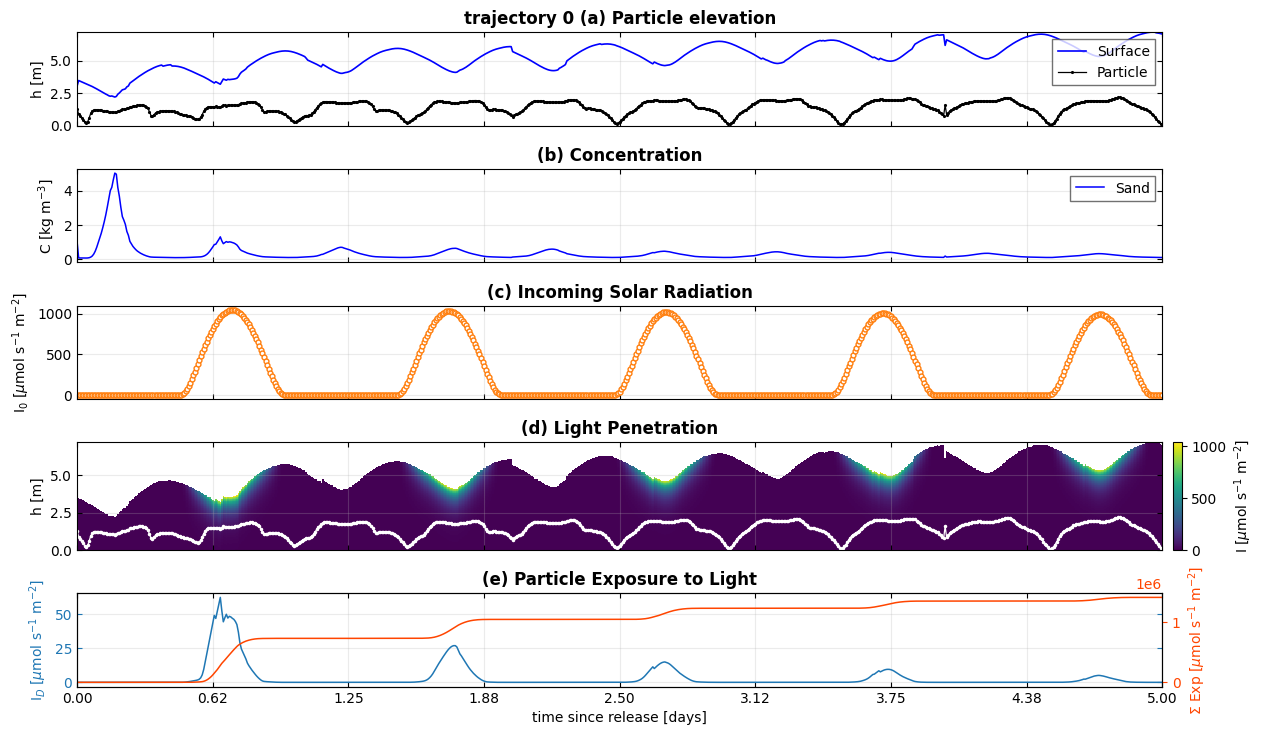

In [30]:
concentration_plot_mode = "sand"  # "sand", "mud", or "combined"

# Choose which attenuation/exposure result to show in the MATLAB-style plot.
if concentration_plot_mode == "sand":
    concentration_for_plot = {"Sand": depth_avg_concentration[:, 0]}
    kd_for_plot = kd_sand[:, 0]
    exposure_for_plot = sand_result
elif concentration_plot_mode == "mud":
    concentration_for_plot = {"Mud": depth_avg_concentration[:, 0]}
    kd_for_plot = kd_mud[:, 0]
    exposure_for_plot = mud_result
elif concentration_plot_mode == "combined":
    concentration_for_plot = {"Total": depth_avg_concentration[:, 0]}
    kd_for_plot = combine_attenuation_components(components["mud"], components["sand"], strategy="additive_excess")[:, 0]
    combined_result = compute_light_exposure(
        track_datetime,
        water_depth_at_particle,
        kd_for_plot[:, None],
        z=particle_elevation_2d,
        z_convention="height_above_bed",
        surface_light=surface_light,
        burial_depth=burial_depth,
        burial_depth_threshold=1e-6,
        in_domain=in_domain,
        is_beached=is_beached,
        light_threshold=0.01,
        reference_surface_light=incoming_solar_constant,
    )
    exposure_for_plot = combined_result
else:
    raise ValueError("concentration_plot_mode must be 'sand', 'mud', or 'combined'")

burial_mask_for_plot = burial_active_mask
particle_elevation_for_plot = particle_elevation_above_bed.copy()
if burial_depth is not None:
    # Panels (a) and (d) are bed-relative: show buried positions as negative depth below bed.
    particle_elevation_for_plot = np.where(
        burial_mask_for_plot,
        -np.abs(burial_depth[:, 0]),
        particle_elevation_for_plot,
    )

# Reload the plotting helper so local source edits are picked up without restarting the kernel.
import importlib
import sedtrails.simulation_analysis.light_exposure_plotting as light_plotting
importlib.reload(light_plotting)

fig, axes = light_plotting.plot_particle_bleaching_potential(
    track_datetime,
    water_depth_at_particle[:, 0],
    particle_elevation_for_plot,
    concentration_for_plot,
    surface_light,
    kd_for_plot,
    exposure_for_plot,
    title_prefix=particle_label,
    concentration_unit="kg m$^{-3}$",
    light_unit="$\\mu$mol s$^{-1}$ m$^{-2}$",
    colormap="viridis",
    burial_mask=burial_mask_for_plot,
    max_x_ticks=matlab_plot_max_x_ticks,
)

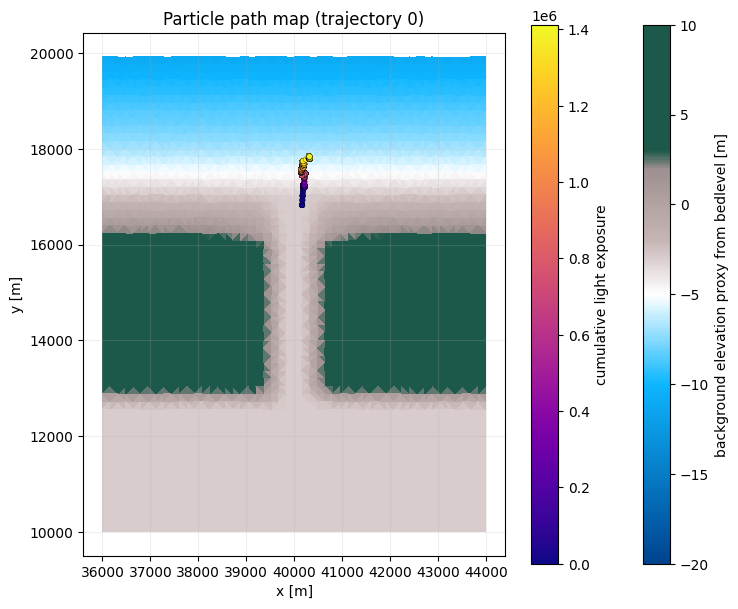

In [31]:
# Map particle position through time on top of the bathymetry
bathy_candidates = ["bedlevel", "bed_level", "bathymetry", "zb", "zbed", "net_node_z"]
bathy_name = next((name for name in bathy_candidates if name in fields), None)

if bathy_name is not None:
    bathy_raw = np.asarray(fields[bathy_name].values, dtype=float)
    if bathy_raw.ndim == 1:
        bathy_map = bathy_raw
    elif bathy_raw.ndim == 2:
        bathy_map = np.nanmean(bathy_raw, axis=0)
    else:
        bathy_map = np.nanmean(bathy_raw.reshape(bathy_raw.shape[0], -1), axis=0)
else:
    # Fallback: infer bed level from depth so we can still use the SedTRAILS palette.
    depth_raw = np.asarray(fields["waterdepth"].values, dtype=float)
    bathy_map = -np.nanmean(depth_raw, axis=0)
    bathy_name = "-mean(waterdepth)"

seawad_cmap, seawad_norm = bathymetry_colormap(map_background_colormap_name)

fig, ax = plt.subplots(figsize=(8.5, 7.0))
# Plot the background field first, then overlay the path colored by cumulative exposure.
background = ax.tripcolor(
    grid_x,
    grid_y,
    bathy_map,
    shading="flat",
    cmap=seawad_cmap,
    norm=seawad_norm,
 )
plt.colorbar(background, ax=ax, label=f"background elevation proxy from {bathy_name} [m]")

cumulative_exposure_for_map = np.asarray(exposure_for_plot.cumulative_light_dose, dtype=float).reshape(track_datetime.size, -1)[:, 0]
ax.plot(
    track_x[:, 0],
    track_y[:, 0],
    color="0.2",
    lw=0.8,
    alpha=0.8,
    zorder=2,
 )
particle_scatter = ax.scatter(
    track_x[:, 0],
    track_y[:, 0],
    c=cumulative_exposure_for_map,
    cmap=map_particle_value_colormap,
    s=map_particle_marker_size,
    edgecolor=map_particle_marker_edgecolor,
    linewidths=map_particle_marker_edgewidth,
    zorder=3,
 )
plt.colorbar(particle_scatter, ax=ax, label="cumulative light exposure")

ax.set_title(f"Particle path map ({particle_label})")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.2)

## Spatial map of all modeled trajectories

This reproduces the particle-path map style, but overlays every modeled trajectory and highlights the currently selected one.

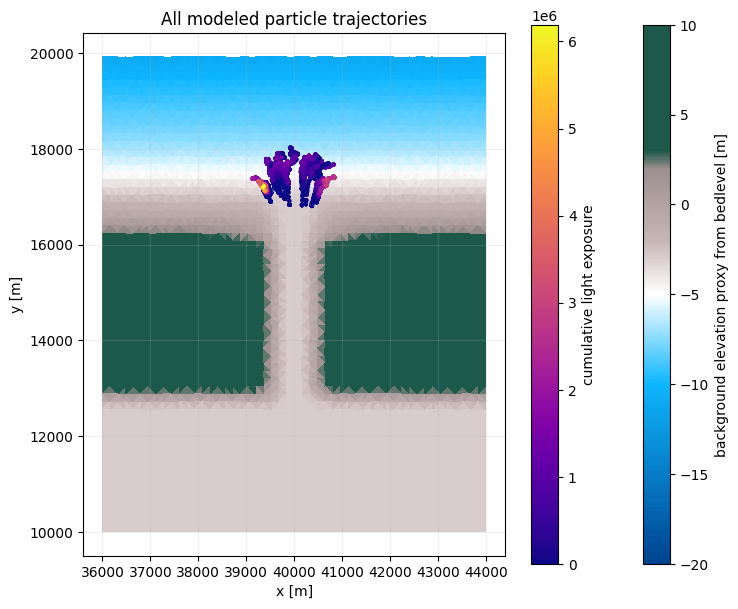

In [32]:
# Recompute the bathymetry background so this map can be run independently of the single-particle map cell.
bathy_candidates = ["bedlevel", "bed_level", "bathymetry", "zb", "zbed", "net_node_z"]
bathy_name = next((name for name in bathy_candidates if name in fields), None)

if bathy_name is not None:
    bathy_raw = np.asarray(fields[bathy_name].values, dtype=float)
    if bathy_raw.ndim == 1:
        bathy_map = bathy_raw
    elif bathy_raw.ndim == 2:
        bathy_map = np.nanmean(bathy_raw, axis=0)
    else:
        bathy_map = np.nanmean(bathy_raw.reshape(bathy_raw.shape[0], -1), axis=0)
else:
    depth_raw = np.asarray(fields["waterdepth"].values, dtype=float)
    bathy_map = -np.nanmean(depth_raw, axis=0)
    bathy_name = "-mean(waterdepth)"

# Sample the forcing fields along every saved trajectory so cumulative exposure can be plotted for all particles.
all_sampled_depth = sample_field_at_trajectories(
    grid_time,
    grid_x,
    grid_y,
    fields["waterdepth"].values,
    track_time,
    all_track_x,
    all_track_y,
    nearest_fallback=True,
    repeat_eulerian_fields=repeat_eulerian_fields,
)
all_sampled_conc = sample_field_at_trajectories(
    grid_time,
    grid_x,
    grid_y,
    fields["suspended_sed_conc"].values,
    track_time,
    all_track_x,
    all_track_y,
    sediment_fraction=0,
    nearest_fallback=True,
    repeat_eulerian_fields=repeat_eulerian_fields,
)

all_sampled_bed_shear = None
if bed_shear_field_name is not None:
    all_sampled_bed_shear = sample_field_at_trajectories(
        grid_time,
        grid_x,
        grid_y,
        fields[bed_shear_field_name].values,
        track_time,
        all_track_x,
        all_track_y,
        nearest_fallback=True,
        repeat_eulerian_fields=repeat_eulerian_fields,
    ).values

all_components = attenuation_from_storlazzi(
    sed_conc_mud=all_sampled_conc.values,
    sed_conc_sand=all_sampled_conc.values,
)

if concentration_plot_mode == "sand":
    kd_all = combine_attenuation_components(all_components["mud"], all_components["sand"], strategy="sand")
elif concentration_plot_mode == "mud":
    kd_all = combine_attenuation_components(all_components["mud"], all_components["sand"], strategy="mud")
elif concentration_plot_mode == "combined":
    kd_all = combine_attenuation_components(all_components["mud"], all_components["sand"], strategy="additive_excess")
else:
    raise ValueError("concentration_plot_mode must be 'sand', 'mud', or 'combined'")

if vertical_position_method == "fixed":
    particle_elevation_all = np.full(all_track_x.shape, float(optional_fixed_vertical_position), dtype=float)
elif vertical_position_method == "macdonald_zc":
    if all_sampled_bed_shear is None:
        raise ValueError("No bed shear stress field found for MacDonald z_c. Update macdonald_bed_shear_field_candidates.")
    grain_size_m = macdonald_grain_size_mm * 1e-3
    grain_props = compute_grain_properties(
        grain_diameter=grain_size_m,
        gravity=macdonald_gravity_m_s2,
        sediment_density=macdonald_sediment_density_kg_m3,
        water_density=macdonald_water_density_kg_m3,
        kinematic_viscosity=macdonald_kinematic_viscosity_m2_s,
    )
    settling_velocity = float(grain_props["settling_velocity"])
    shear_velocity_all = compute_shear_velocity(
        np.maximum(all_sampled_bed_shear, 0.0),
        water_density=macdonald_water_density_kg_m3,
    )
    denominator_all = macdonald_vkarman * shear_velocity_all
    ratio_all = np.full(all_track_x.shape, np.nan, dtype=float)
    valid_all = np.isfinite(denominator_all) & (denominator_all > 0.0)
    np.divide(settling_velocity, denominator_all, out=ratio_all, where=valid_all)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        zc_fraction_all = 0.0398 * 10.0 ** (-1.08 * np.tanh(1.2 * np.log(ratio_all) - 0.4))
    particle_elevation_all = np.clip(
        all_sampled_depth.values * zc_fraction_all,
        0.0,
        all_sampled_depth.values,
    )
elif vertical_position_method == "saved_z_or_zero":
    if "z" in tracks and np.isfinite(tracks["z"].values).any() and np.nanmin(tracks["z"].values.astype(float)) >= -1e-6:
        particle_elevation_all = np.clip(tracks["z"].values.astype(float), 0.0, all_sampled_depth.values)
    else:
        particle_elevation_all = np.zeros(all_track_x.shape, dtype=float)
else:
    raise ValueError("vertical_position_method must be 'fixed', 'saved_z_or_zero', or 'macdonald_zc'")

if analysis_mode == "source" and not apply_trajectory_burial_in_source_mode:
    burial_depth_all = None
    status_buried_all = np.zeros(all_track_x.shape, dtype=bool)
    in_domain_all = None
    is_beached_all = None
else:
    burial_depth_all = tracks["burial_depth"].values.astype(float) if "burial_depth" in tracks else None
    status_buried_all = tracks["status_buried"].values.astype(bool) if "status_buried" in tracks else None
    if status_buried_all is None and burial_depth_all is not None:
        status_buried_all = burial_depth_all > 1e-6
    if status_buried_all is None:
        status_buried_all = np.zeros(all_track_x.shape, dtype=bool)
    in_domain_all = tracks["status_domain"].values.astype(bool) if "status_domain" in tracks else None
    is_beached_all = tracks["status_beached"].values.astype(bool) if "status_beached" in tracks else None

burial_mask_all = status_buried_all.copy()
if burial_depth_all is not None:
    burial_mask_all = burial_mask_all | (burial_depth_all > 1e-6)

if vertical_position_method == "macdonald_zc" and burial_depth_all is not None:
    particle_elevation_all = np.where(
        burial_mask_all,
        np.clip(burial_depth_all, 0.0, all_sampled_depth.values),
        particle_elevation_all,
    )

all_result = compute_light_exposure(
    track_datetime,
    all_sampled_depth.values,
    kd_all,
    z=particle_elevation_all,
    z_convention="height_above_bed",
    surface_light=surface_light,
    burial_depth=burial_depth_all,
    burial_depth_threshold=1e-6,
    in_domain=in_domain_all,
    is_beached=is_beached_all,
    light_threshold=0.01,
    reference_surface_light=incoming_solar_constant,
)

seawad_cmap, seawad_norm = bathymetry_colormap(map_background_colormap_name)

fig, ax = plt.subplots(figsize=(8.5, 7.0))
background = ax.tripcolor(
    grid_x,
    grid_y,
    bathy_map,
    shading="flat",
    cmap=seawad_cmap,
    norm=seawad_norm,
)
plt.colorbar(background, ax=ax, label=f"background elevation proxy from {bathy_name} [m]")

# Draw every modeled trajectory faintly, then color the saved particle locations by cumulative exposure.
for particle in range(all_track_x.shape[1]):
    ax.plot(
        all_track_x[:, particle],
        all_track_y[:, particle],
        color="0.4",
        lw=0.5,
        alpha=0.2,
        zorder=2,
    )

all_cumulative_exposure = np.asarray(all_result.cumulative_light_dose, dtype=float)
valid_points = np.isfinite(all_track_x) & np.isfinite(all_track_y) & np.isfinite(all_cumulative_exposure)
particle_scatter = ax.scatter(
    all_track_x[valid_points],
    all_track_y[valid_points],
    c=all_cumulative_exposure[valid_points],
    cmap=map_particle_value_colormap,
    s=max(4, map_particle_marker_size - 6),
    edgecolor="none",
    zorder=3,
)
plt.colorbar(particle_scatter, ax=ax, label="cumulative light exposure")

ax.set_title("All modeled particle trajectories")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.2)

## Particle depth and burial

The shaded intervals show timesteps where burial depth exceeds the light-exposure burial threshold.

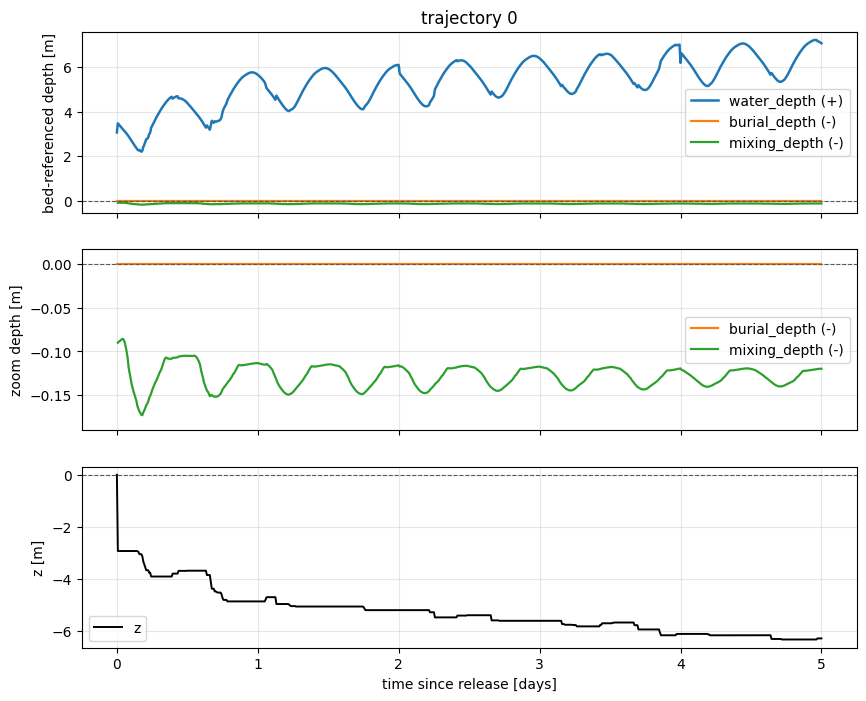

In [33]:
time_days = (track_datetime - track_datetime[0]).astype("timedelta64[s]").astype(float) / 86400.0

particle_index = 0
water_depth_series = water_depth_at_particle[:, particle_index].astype(float)
burial_series = np.zeros(track_time.shape, dtype=float) if burial_depth is None else burial_depth[:, particle_index].astype(float)
mixing_series = np.zeros(track_time.shape, dtype=float) if mixing_depth is None else mixing_depth[:, particle_index].astype(float)
buried = np.zeros(track_time.shape, dtype=bool) if status_buried is None else status_buried[:, particle_index].astype(bool)
z_series = (
    tracks["z"].values[:, selected_particle_index].astype(float)
    if "z" in tracks
    else particle_elevation_above_bed.astype(float)
 )

# Plot burial and mixing below zero so everything is referenced to the bed line.
burial_neg = -burial_series
mixing_neg = -mixing_series

fig, axes = plt.subplots(3, 1, figsize=(10, 8.0), sharex=True, gridspec_kw={"hspace": 0.2})
ax_top, ax_zoom, ax_bottom = axes

# Panel 1: bed-referenced diagnostics (above-bed positive, below-bed negative).
ax_top.plot(time_days, water_depth_series, color="tab:blue", lw=1.8, label="water_depth (+)")
ax_top.plot(time_days, burial_neg, color="tab:orange", lw=1.6, label="burial_depth (-)")
ax_top.plot(time_days, mixing_neg, color="tab:green", lw=1.6, label="mixing_depth (-)")
ax_top.axhline(0.0, color="0.35", lw=0.8, ls="--")

# Panel 2: zoom near bed for burial and mixing depth.
ax_zoom.plot(time_days, burial_neg, color="tab:orange", lw=1.6, label="burial_depth (-)")
ax_zoom.plot(time_days, mixing_neg, color="tab:green", lw=1.6, label="mixing_depth (-)")
ax_zoom.axhline(0.0, color="0.35", lw=0.8, ls="--")
max_zoom = np.nanmax(np.abs(np.r_[burial_neg, mixing_neg]))
if np.isfinite(max_zoom) and max_zoom > 0:
    ax_zoom.set_ylim(-1.1 * max_zoom, 0.1 * max_zoom)

# Panel 3: raw trajectory z only.
ax_bottom.plot(time_days, z_series, color="black", lw=1.4, label="z")
ax_bottom.axhline(0.0, color="0.35", lw=0.8, ls="--")

# Reuse the buried-status intervals as grey shading across all three panels.
transitions = np.diff(np.r_[0, buried.astype(np.int8), 0])
starts = np.flatnonzero(transitions == 1)
stops = np.flatnonzero(transitions == -1)
for start, stop in zip(starts, stops):
    right = time_days[max(stop - 1, start)]
    if right == time_days[start] and start + 1 < time_days.size:
        right = time_days[start + 1]
    ax_top.axvspan(time_days[start], right, color="0.8", alpha=0.28, lw=0)
    ax_zoom.axvspan(time_days[start], right, color="0.8", alpha=0.28, lw=0)
    ax_bottom.axvspan(time_days[start], right, color="0.8", alpha=0.28, lw=0)

ax_top.set_ylabel("bed-referenced depth [m]")
ax_zoom.set_ylabel("zoom depth [m]")
ax_bottom.set_ylabel("z [m]")
ax_bottom.set_xlabel("time since release [days]")
ax_top.set_title(particle_label)
ax_top.grid(True, alpha=0.3)
ax_zoom.grid(True, alpha=0.3)
ax_bottom.grid(True, alpha=0.3)
ax_top.legend(loc="best")
ax_zoom.legend(loc="best")
ax_bottom.legend(loc="best")

## Next steps

- Confirm the vertical convention for saved trajectory `z` and replace the near-bed approximation.
- Split sand and mud concentration inputs when both fields are available.
- Save the sampled path fields and exposure diagnostics to NetCDF once the variable names stabilize.
- Replace placeholder bleaching and OSL signal arrays with colleague-provided equations.

## Save Luminescence Data to Netcdf File

In [35]:
# Optional export: save a luminescence-augmented copy of the trajectory file.
SAVE_LUM_TRAJECTORY = False

if SAVE_LUM_TRAJECTORY:
    tracks_source = tracks_full if "tracks_full" in globals() else tracks
    tracks_out = tracks_source.copy(deep=True)

    # Resolve trajectory dimensions from the full output dataset.
    trajectory_template = None
    for candidate in ("x", "lon", "longitude", "y", "lat", "latitude"):
        if candidate in tracks_out:
            trajectory_template = tracks_out[candidate]
            break
    if trajectory_template is None:
        raise KeyError("Could not infer trajectory dimensions from tracks (expected x/y or lon/lat variables).")

    full_dims = trajectory_template.dims
    full_shape = trajectory_template.shape

    cumulative_exposure_values = np.asarray(all_cumulative_exposure, dtype=float)
    assumed_particle_z_values = np.asarray(particle_elevation_all, dtype=float)

    # Expand sand-only diagnostics back to full trajectory shape (non-sand stays NaN).
    if cumulative_exposure_values.shape != full_shape:
        if "sand_particle_indices" not in globals() or cumulative_exposure_values.shape[1] != len(sand_particle_indices):
            raise ValueError(
                f"all_cumulative_exposure has shape {cumulative_exposure_values.shape}, expected {full_shape} or sand-only shape."
            )
        expanded_cumulative = np.full(full_shape, np.nan, dtype=float)
        expanded_cumulative[:, sand_particle_indices] = cumulative_exposure_values
        cumulative_exposure_values = expanded_cumulative

    if assumed_particle_z_values.shape != full_shape:
        if "sand_particle_indices" not in globals() or assumed_particle_z_values.shape[1] != len(sand_particle_indices):
            raise ValueError(
                f"particle_elevation_all has shape {assumed_particle_z_values.shape}, expected {full_shape} or sand-only shape."
            )
        expanded_z = np.full(full_shape, np.nan, dtype=float)
        expanded_z[:, sand_particle_indices] = assumed_particle_z_values
        assumed_particle_z_values = expanded_z

    coord_map = {dim: tracks_out.coords[dim] for dim in full_dims if dim in tracks_out.coords}

    tracks_out["cumulative_exposure"] = xr.DataArray(
        cumulative_exposure_values,
        dims=full_dims,
        coords=coord_map,
        attrs={
            "long_name": "cumulative light exposure",
            "description": "Cumulative exposure computed in this notebook (sand trajectories only; non-sand set to NaN)",
        },
    )
    tracks_out["assumed_particle_z"] = xr.DataArray(
        assumed_particle_z_values,
        dims=full_dims,
        coords=coord_map,
        attrs={
            "long_name": "assumed particle z",
            "description": "Particle vertical position used in exposure calculations (sand trajectories only; non-sand set to NaN)",
            "z_convention": "height_above_bed",
            "units": "m",
        },
    )

    lum_trajectory_path = trajectory_path.with_name(f"{trajectory_path.stem}_lum{trajectory_path.suffix}")
    tracks_out.to_netcdf(lum_trajectory_path)
    print(f"Saved luminescence-augmented trajectory file: {lum_trajectory_path}")
else:
    print("Skipping export. Set SAVE_LUM_TRAJECTORY = True to write a _lum NetCDF file.")

Skipping export. Set SAVE_LUM_TRAJECTORY = True to write a _lum NetCDF file.
